In [ ]:
import importlib
import numpy as np
from astropy import units as u

import debris_generator
import orbit_propagator
import satellite_maneuver

importlib.reload(debris_generator)
importlib.reload(orbit_propagator)
importlib.reload(satellite_maneuver)

from debris_generator import check_conjunction, generate_debris
from orbit_propagator import create_satellite_orbit, propagate_orbit
from satellite_maneuver import apply_maneuver


In [ ]:
orbit = create_satellite_orbit()

simulation_time = 90 * u.min
steps = 200

times = np.linspace(0, simulation_time.value, steps) * u.min

debris_orbits = generate_debris(50)

#Storage Arrays:
sat_positions = []
debris_positions_over_time = []

In [ ]:
for t in times:

    # propagate satellite
    sat_state = orbit.propagate(t)
    sat_pos = sat_state.r.value
    sat_positions.append(sat_pos)

    debris_positions = []

    # propagate debris
    for debris in debris_orbits:

        debris_state = debris.propagate(t)
        debris_pos = debris_state.r.value

        debris_positions.append(debris_pos)

    debris_positions_over_time.append(debris_positions)

In [ ]:
#Converting to arrays:
sat_positions = np.array(sat_positions)
debris_positions_over_time = np.array(debris_positions_over_time)

In [ ]:
print(sat_positions.shape)
print(debris_positions_over_time.shape)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# satellite orbit path
ax.plot(
    sat_positions[:,0],
    sat_positions[:,1],
    sat_positions[:,2],
    label="Satellite"
)

# debris at final timestep
final_debris = debris_positions_over_time[-1]

ax.scatter(
    final_debris[:,0],
    final_debris[:,1],
    final_debris[:,2],
    s=5,
    color="red",
    label="Debris"
)

ax.legend()
plt.show()

In [ ]:
#Collision Detextion:

threshold = 500  # km

close_approaches = []

for i in range(len(times)):

    sat = sat_positions[i]

    debris_positions = debris_positions_over_time[i]

    for j, debris in enumerate(debris_positions):

        distance = np.linalg.norm(sat - debris)

        if distance < threshold:

            close_approaches.append((i, j, distance))

In [ ]:
print(close_approaches[:10])

In [ ]:
# closest approach over the whole simulation

min_distance = np.inf
closest_event = None

for i in range(len(times)):

    sat = sat_positions[i]
    debris_positions = debris_positions_over_time[i]

    for j, debris in enumerate(debris_positions):

        distance = np.linalg.norm(sat - debris)

        if distance < min_distance:

            min_distance = distance
            closest_event = (i, j)

#Checking the result:
print("Minimum distance:", min_distance)  #How close it got
print("Time index:", closest_event[0])  #When this closest approach happened
print("Debris index:", closest_event[1])

In [ ]:
#Time of cloisest approach:
tca_index = closest_event[0]
debris_index = closest_event[1]

print("Time of closest approach:", times[tca_index])

#We need the positions:
sat_tca = sat_positions[tca_index]
debris_tca = debris_positions_over_time[tca_index][debris_index]

In [ ]:
window = 10

start = max(tca_index - window, 0)
end = min(tca_index + window, len(times))

sat_segment = sat_positions[start:end]

debris_segment = []

for k in range(start, end):
    debris_segment.append(debris_positions_over_time[k][debris_index])

debris_segment = np.array(debris_segment)

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    sat_segment[:,0],
    sat_segment[:,1],
    sat_segment[:,2],
    label="Satellite"
)

ax.plot(
    debris_segment[:,0],
    debris_segment[:,1],
    debris_segment[:,2],
    label="Debris"
)

ax.scatter(
    sat_tca[0],
    sat_tca[1],
    sat_tca[2],
    s=80,
    label="Closest Approach"
)

ax.legend()
plt.show()

## Collision risk depends on relative velocity, not just distance

In [ ]:
sat_state = orbit.propagate(times[tca_index])
debris_state = debris_orbits[debris_index].propagate(times[tca_index])

v_rel = sat_state.v.value - debris_state.v.value
v_rel_mag = np.linalg.norm(v_rel)

print("Relative velocity (km/s):", v_rel_mag)

## Collision Avoidance System Demo

This section uses the production modules to run an end-to-end conjunction detection and avoidance simulation, then generates a labeled dataset for downstream ML experiments.


In [1]:
import importlib
from astropy import units as u

import dataset_generator
import orbit_propagator
import simulation_engine

importlib.reload(dataset_generator)
importlib.reload(orbit_propagator)
importlib.reload(simulation_engine)

from dataset_generator import generate_conjunction_dataset
from orbit_propagator import create_satellite_orbit
from simulation_engine import SimulationConfig, SimulationEngine

sat_orbit = create_satellite_orbit()

engine_config = SimulationConfig(
    duration=10 * u.hour,
    timestep=30 * u.s,
    debris_count=200,
    conjunction_threshold_km=100.0,
    maneuver_threshold_km=85.0,
    closest_approach_window=20 * u.min,
    include_j2=True,
)

engine = SimulationEngine(config=engine_config)
results = engine.run(sat_orbit)
print('J2 perturbation enabled:', results['config'].include_j2)


J2 perturbation enabled: True


In [2]:
print(f"States logged: {len(results['state_history'])}")
print(f"Conjunction events: {len(results['conjunctions'])}")
print(f"Avoidance maneuvers: {len(results['maneuvers'])}")

if results['conjunctions']:
    top_event = min(results['conjunctions'], key=lambda event: event['min_distance'])
    print('Closest predicted event:')
    print(top_event)
else:
    print('No conjunctions detected in this run.')


States logged: 1201
Conjunction events: 5
Avoidance maneuvers: 4
Closest predicted event:
{'debris_index': 6, 'distance_km': 28.600207255788938, 'threshold_km': 100.0, 'step': 1038, 'epoch': <Time object: scale='tdb' format='jyear_str' value=J2000.001>, 'tca': <Time object: scale='tdb' format='jyear_str' value=J2000.001>, 'tca_offset_s': 3.1126526522985385, 'min_distance': 20.249768972941087, 'success': True}


In [3]:
dataset_rows = generate_conjunction_dataset(
    output_csv='conjunction_dataset.csv',
    n_samples=1000,
    time_window=30 * u.min,
    collision_threshold_km=1.0,
    random_state=42,
)

print(f"Dataset rows written: {len(dataset_rows)}")
print('Saved to conjunction_dataset.csv')


Dataset rows written: 1000
Saved to conjunction_dataset.csv


## Visualization Dashboard

These cells use `visualization.py` to plot Earth, the nominal satellite orbit, a debris cloud, and any avoidance maneuver locations from the simulation results.


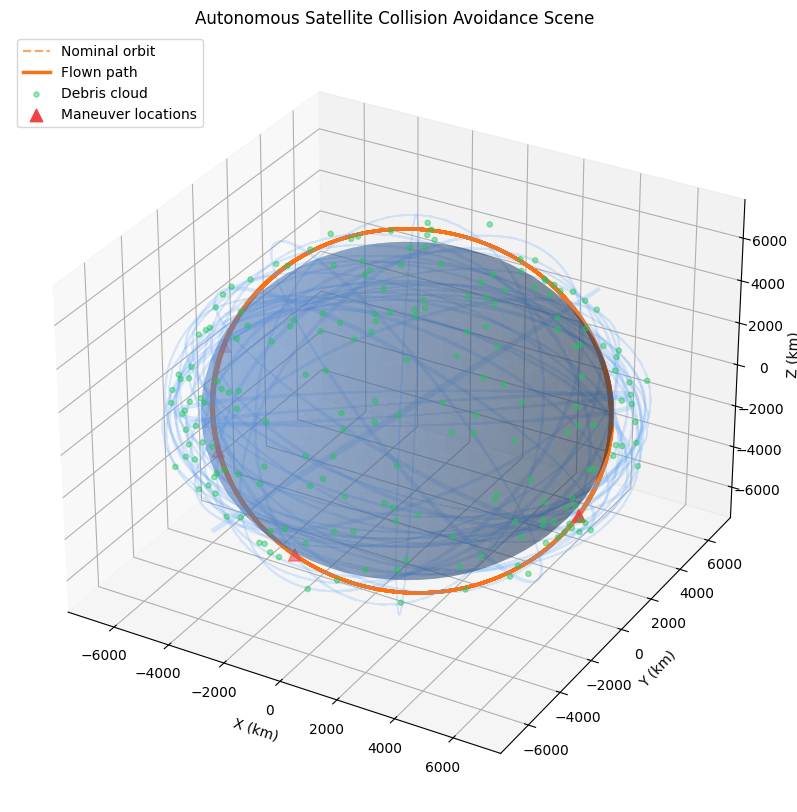

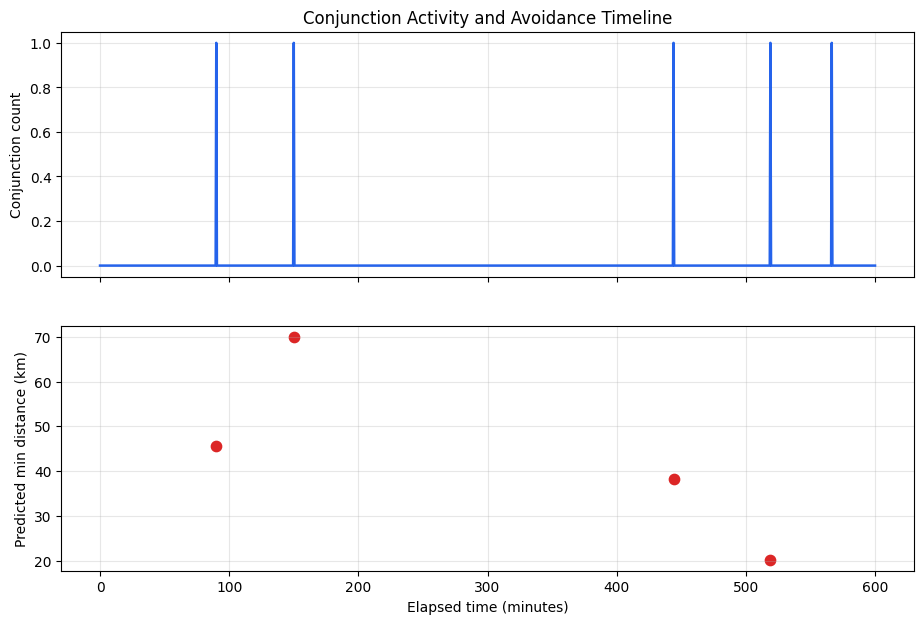

In [4]:
import importlib
import matplotlib.pyplot as plt
import visualization

importlib.reload(visualization)

scene, timeline = visualization.plot_results_overview(
    results,
    samples=350,
    max_debris_tracks=30,
)
plt.show()


In [5]:
if results['maneuvers']:
    print('Maneuver summary:')
    for maneuver in results['maneuvers'][:10]:
        print(
            f"Step {maneuver['step']}: debris #{maneuver['trigger_debris_index']} | "
            f"predicted min distance = {maneuver['predicted_min_distance_km']:.3f} km | "
            f"delta-v = {maneuver['delta_v_m_s']:.3f} m/s"
        )
else:
    print('No avoidance maneuvers were triggered in this run.')


Maneuver summary:
Step 180: debris #138 | predicted min distance = 45.662 km | delta-v = 0.250 m/s
Step 300: debris #159 | predicted min distance = 69.995 km | delta-v = 0.250 m/s
Step 888: debris #32 | predicted min distance = 38.320 km | delta-v = 0.250 m/s
Step 1038: debris #6 | predicted min distance = 20.250 km | delta-v = 0.250 m/s


## Real CelesTrak Data Demo

This section fetches live public TLE data from CelesTrak, propagates it with `sgp4`, and visualizes a real catalog snapshot. This is the first step toward a hybrid physics + ML system using real orbital data.


Fetched 12 real CelesTrak objects from the STATIONS group.
Closest pair in the snapshot:
{'object_1': 'ISS (ZARYA)', 'object_2': 'POISK', 'distance_km': 0.0, 'timestamp_utc': datetime.datetime(2026, 3, 14, 22, 19, 58, 367542, tzinfo=datetime.timezone.utc)}


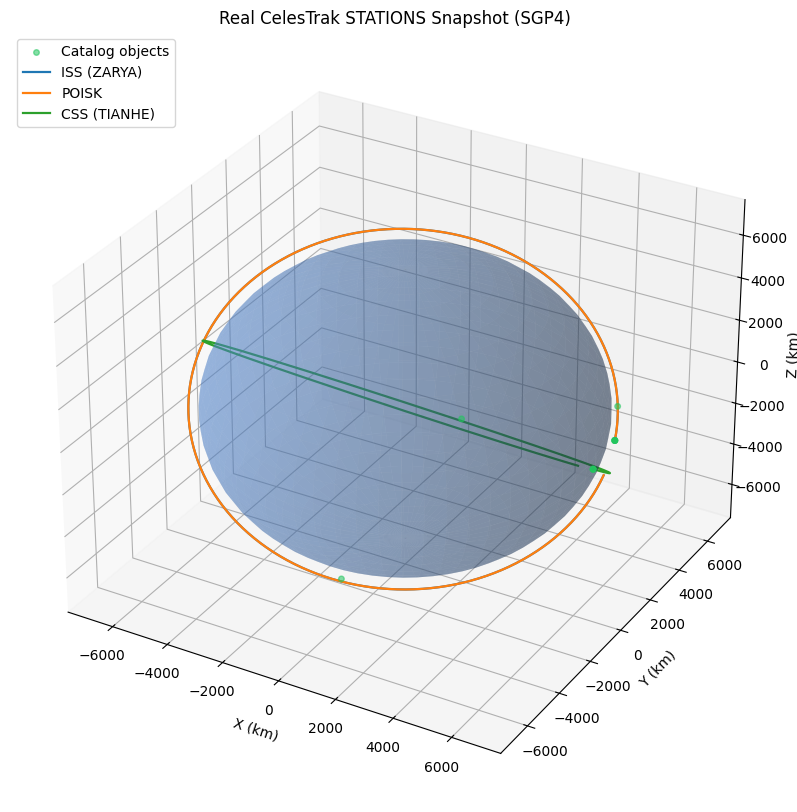

In [6]:
import importlib
from datetime import UTC, datetime
import matplotlib.pyplot as plt

import real_data_loader
import visualization

importlib.reload(real_data_loader)
importlib.reload(visualization)

from real_data_loader import fetch_tle_group, find_closest_pair, propagate_tle_group, sample_tle_track
from visualization import plot_real_catalog_scene

snapshot_time = datetime.now(UTC)
real_records = fetch_tle_group(group='stations', limit=12)
real_snapshot = propagate_tle_group(real_records, when=snapshot_time)

tracked_real_objects = [
    {
        'name': record.name,
        'track_km': sample_tle_track(record, minutes=90, samples=160, start_time=snapshot_time),
    }
    for record in real_records[:3]
]

closest_real_pair = find_closest_pair(real_snapshot)
print(f"Fetched {len(real_records)} real CelesTrak objects from the STATIONS group.")
print('Closest pair in the snapshot:')
print(closest_real_pair)

real_scene = plot_real_catalog_scene(
    real_snapshot,
    tracked_objects=tracked_real_objects,
    title='Real CelesTrak STATIONS Snapshot (SGP4)',
)
plt.show()


## Machine Learning Screening Demo

This section regenerates a balanced conjunction dataset, trains a collision-risk classifier and a delta-v regressor, and benchmarks inference speed. The ML model is used as a fast screening layer on top of the physics simulator.


In [7]:
import importlib
from astropy import units as u

import dataset_generator
import ml_model

importlib.reload(dataset_generator)
importlib.reload(ml_model)

from dataset_generator import generate_conjunction_dataset
from ml_model import dataset_summary, load_dataset

ml_rows = generate_conjunction_dataset(
    output_csv='conjunction_dataset_ml.csv',
    n_samples=2000,
    time_window=30 * u.min,
    collision_threshold_km=25.0,
    positive_scenario_fraction=0.4,
    random_state=42,
)

ml_dataset = load_dataset('conjunction_dataset_ml.csv')
ml_summary = dataset_summary(ml_dataset)
print(ml_summary)


{'rows': 2000, 'positive_collision_risk': 807, 'negative_collision_risk': 1193, 'positive_fraction': 0.4035, 'nonzero_delta_v': 807}


In [8]:
from ml_model import (
    benchmark_inference,
    save_model,
    train_delta_v_regressor,
    train_risk_classifier,
)

risk_result = train_risk_classifier(ml_dataset, random_state=42)
delta_v_result = train_delta_v_regressor(ml_dataset, random_state=42)

save_model(risk_result['model'], 'collision_risk_classifier.joblib')
save_model(delta_v_result['model'], 'delta_v_regressor.joblib')

print('Risk classifier metrics:')
print(risk_result['metrics'])
print()
print('Delta-v regressor metrics:')
print(delta_v_result['metrics'])

risk_benchmark = benchmark_inference(risk_result['model'], ml_dataset, n_runs=200)
delta_v_benchmark = benchmark_inference(delta_v_result['model'], ml_dataset, n_runs=200)

print()
print('Inference benchmark:')
print({'risk_classifier': risk_benchmark, 'delta_v_regressor': delta_v_benchmark})


Risk classifier metrics:
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0, 'confusion_matrix': [[298, 0], [0, 202]]}

Delta-v regressor metrics:
{'mae': 0.14803060251587266, 'mean_target': 1.6153107720915578}

Inference benchmark:
{'risk_classifier': {'samples': 2000, 'runs': 200, 'average_inference_ms': 66.0968705000414}, 'delta_v_regressor': {'samples': 2000, 'runs': 200, 'average_inference_ms': 43.27543499995954}}


In [9]:
sample_features = ml_dataset[0]
feature_vector = [[float(sample_features[column]) for column in risk_result['feature_columns']]]

predicted_risk = int(risk_result['model'].predict(feature_vector)[0])
predicted_risk_score = float(risk_result['model'].predict_proba(feature_vector)[0, 1])
predicted_delta_v = float(delta_v_result['model'].predict(feature_vector)[0])

print('Sample scenario prediction:')
print({
    'predicted_collision_risk': predicted_risk,
    'predicted_risk_score': predicted_risk_score,
    'predicted_required_delta_v': predicted_delta_v,
    'true_collision_risk': int(float(sample_features['collision_risk'])),
    'true_required_delta_v': float(sample_features['required_delta_v']),
})


Sample scenario prediction:
{'predicted_collision_risk': 0, 'predicted_risk_score': 0.0, 'predicted_required_delta_v': 1.4505050342406807, 'true_collision_risk': 0, 'true_required_delta_v': 0.0}
